In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [2]:
# =========================
# Imports
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
# =========================
# Device (GPU if available)
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# =========================
# Load Dataset
# =========================
df = pd.read_csv('./Churn_Modelling.csv')

df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)

In [5]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [6]:
# =========================
# Train Test Split
# =========================
X = df.drop(columns=['Exited'])
y = df['Exited'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [7]:
# =========================
# Scaling
# =========================
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [8]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train_trf, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_trf, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1).to(device)


In [9]:
# =========================
# Model Definition
# =========================
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, input_dim=11):
        
        super(Model, self).__init__()
        
        # Grouping layers into a Sequential block for cleaner code
        self.main = nn.Sequential(
            nn.Linear(input_dim, 11),
            nn.Sigmoid(),
            nn.Linear(11, 11),
            nn.Sigmoid(),
            nn.Linear(11, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.main(x)

# Initialization
model = Model().to(device)

In [10]:
# =========================
# Loss and Optimizer
# =========================
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

In [11]:
# =========================
# Training
# =========================
epochs = 100
batch_size = 50

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(epochs):
    
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    
    epoch_loss = 0
    correct = 0
    
    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train[indices]
        batch_y = y_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        predicted = (outputs >= 0.5).float()
        correct += (predicted == batch_y).sum().item()
    
    train_acc = correct / len(X_train)
    
    # ================= Validation =================
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
        val_pred = (val_outputs >= 0.5).float()
        val_acc = (val_pred == y_test).sum().item() / len(X_test)
    
    history['loss'].append(epoch_loss)
    history['val_loss'].append(val_loss.item())
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Loss: {epoch_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Acc: {train_acc:.4f}, "
          f"Val Acc: {val_acc:.4f}")

Epoch 1/100, Loss: 85.8961, Val Loss: 0.4991, Acc: 0.7960, Val Acc: 0.7975
Epoch 2/100, Loss: 79.1405, Val Loss: 0.4869, Acc: 0.7960, Val Acc: 0.7975
Epoch 3/100, Loss: 77.4031, Val Loss: 0.4747, Acc: 0.7960, Val Acc: 0.7975
Epoch 4/100, Loss: 75.3238, Val Loss: 0.4612, Acc: 0.7960, Val Acc: 0.7975
Epoch 5/100, Loss: 73.1161, Val Loss: 0.4464, Acc: 0.7960, Val Acc: 0.7975
Epoch 6/100, Loss: 71.1010, Val Loss: 0.4351, Acc: 0.7960, Val Acc: 0.7975
Epoch 7/100, Loss: 69.7571, Val Loss: 0.4288, Acc: 0.7963, Val Acc: 0.8020
Epoch 8/100, Loss: 69.0001, Val Loss: 0.4252, Acc: 0.8020, Val Acc: 0.8115
Epoch 9/100, Loss: 68.5918, Val Loss: 0.4225, Acc: 0.8093, Val Acc: 0.8105
Epoch 10/100, Loss: 68.3679, Val Loss: 0.4217, Acc: 0.8109, Val Acc: 0.8095
Epoch 11/100, Loss: 68.1941, Val Loss: 0.4200, Acc: 0.8111, Val Acc: 0.8110
Epoch 12/100, Loss: 68.0403, Val Loss: 0.4189, Acc: 0.8123, Val Acc: 0.8140
Epoch 13/100, Loss: 67.8611, Val Loss: 0.4185, Acc: 0.8145, Val Acc: 0.8160
Epoch 14/100, Loss: 6

In [12]:
# =========================
# Prediction
# =========================
model.eval()
with torch.no_grad():
    y_pred = model(X_test)

y_pred = (y_pred >= 0.5).float()

# Move tensors back to CPU for sklearn
accuracy_score(y_test.cpu().numpy(), y_pred.cpu().numpy())

0.8465

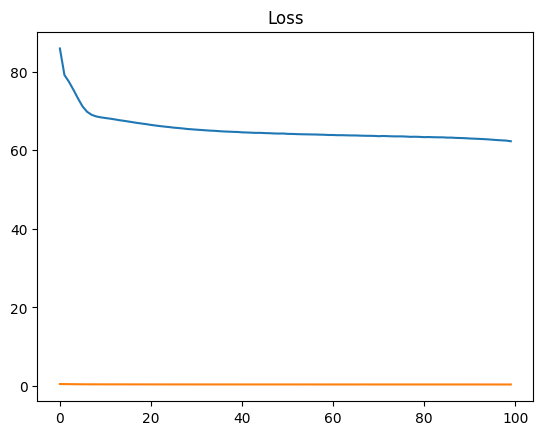

In [13]:
# =========================
# Plot Loss
# =========================
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title("Loss")
plt.show()


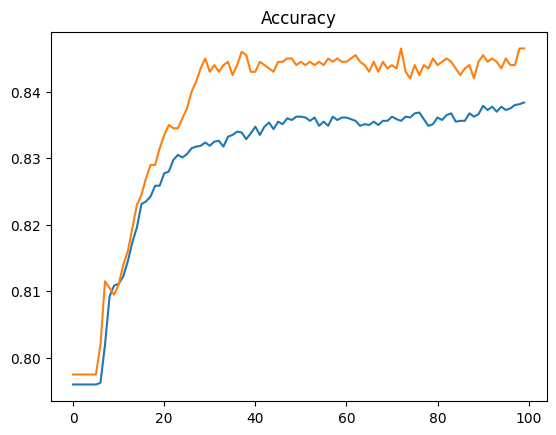

In [14]:
# =========================
# Plot Accuracy
# =========================
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title("Accuracy")
plt.show()

In [15]:
import pickle

# Save
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
